In [3]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 랜덤포레스트의 특성 중요도 확인

* 아이리스 데이터를 학습한 뒤, 각 특성(꽃 길이·너비 등)이 얼마나 중요한지 시각화
* 즉, “어떤 변수가 분류에 제일 영향이 컸는가?”

[0.09090795 0.02453104 0.46044474 0.42411627]
[2 3 0 1]


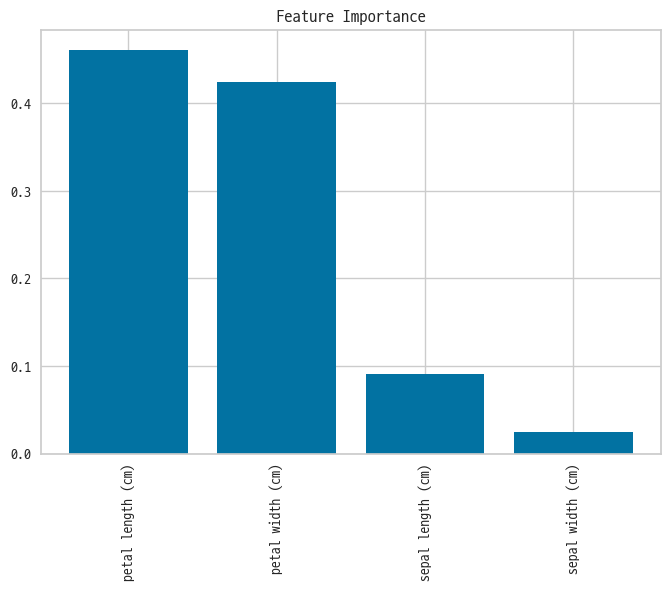

In [ ]:
iris = datasets.load_iris()
features = iris.data
target = iris.target

randomforest = RandomForestClassifier(random_state=0,n_estimators=100, n_jobs=-1)

# 분할하지 않았다

model = randomforest.fit(features, target)

# 특성 중요도 계산 (각 변수의 중요도 점수)
importances = model.feature_importances_
print(importances)   ## 세번째 변수가 가장 중요

# 특성 중요도를 기준으로 내림차순으로 정렬
idx = np.argsort(importances)[::-1]   # [::-1] => 뒤집기(내림차순 정렬),  np.argsort => 값을 정렬했을 때의 위치(인덱스 번호)를 알려주는 함수
print(idx)

# 정렬된 특성 중요도에 따라 특성의 이름을 나열
names = [iris.feature_names[i] for i in idx]


plt.figure()
plt.title("Feature Importance")
plt.bar(range(features.shape[1]), importances[idx])
plt.xticks(range(features.shape[1]), names, rotation=90)
plt.show()


# model.feature_importances_   # 특성 중요도

[0.02429854 0.01419575 0.0539929  0.04540104 0.00795465 0.00345576
 0.07186229 0.08852713 0.00558817 0.0021412  0.01900904 0.00490146
 0.01459376 0.0394196  0.00374584 0.00366822 0.00424091 0.00508478
 0.00371126 0.0059118  0.12198315 0.0191726  0.17398717 0.07498058
 0.01269208 0.01023589 0.03039391 0.11858904 0.00796357 0.0082979 ]
[22 20 27  7 23  6  2  3 13 26  0 21 10 12  1 24 25 29 28  4 19  8 17 11
 16 14 18 15  5  9]


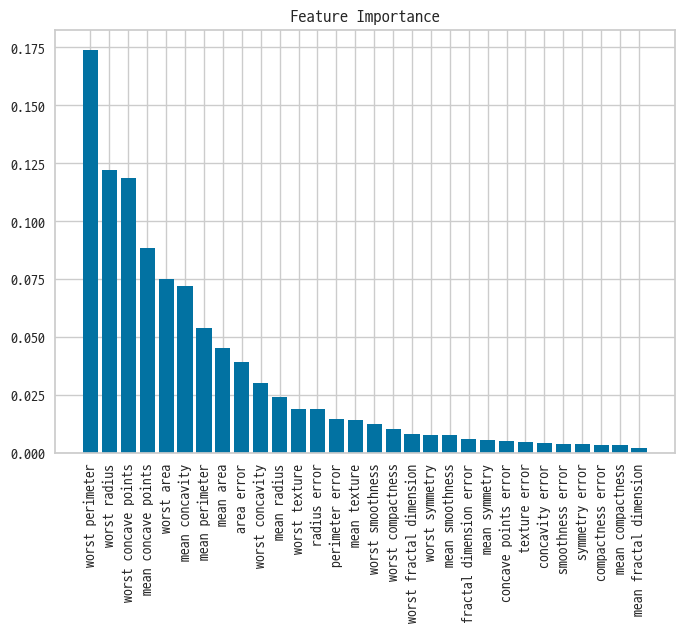

In [6]:
b_cancer = datasets.load_breast_cancer()
features = b_cancer.data
target = b_cancer.target

randomforest = RandomForestClassifier(random_state=0,n_estimators=100, n_jobs=-1)

# 분할하지 않았다

model = randomforest.fit(features, target)

# 특성 중요도 계산 (각 변수의 중요도 점수)
importances = model.feature_importances_
print(importances)   ## 세번째 변수가 가장 중요

# 특성 중요도를 기준으로 내림차순으로 정렬
idx = np.argsort(importances)[::-1]   # [::-1] => 뒤집기(내림차순 정렬),  np.argsort => 값을 정렬했을 때의 위치(인덱스 번호)를 알려주는 함수
print(idx)

# 정렬된 특성 중요도에 따라 특성의 이름을 나열
names = [b_cancer.feature_names[i] for i in idx]


plt.figure()
plt.title("Feature Importance")
plt.bar(range(features.shape[1]), importances[idx])
plt.xticks(range(features.shape[1]), names, rotation=90)
plt.show()


# model.feature_importances_   # 특성 중요도